In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [163]:
df.shape

(768, 9)

In [164]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [165]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [166]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [168]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [169]:
df["Outcome"].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

## Initial Data Understanding

In this step, I explored the dataset structure, checked the column names, data types, missing values, summary statistics, and the distribution of the target column `Outcome`.

The target column is `Outcome`:
- 0 means the patient does not have diabetes
- 1 means the patient has diabetes

In [170]:
# Show the percentage of each class
outcome_percentage = df["Outcome"].value_counts(normalize=True) * 100

outcome_percentage

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

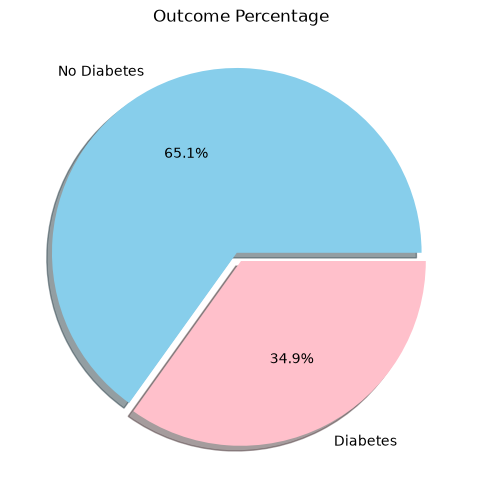

In [171]:
plt.figure(figsize=(6,6))
plt.pie(outcome_percentage.values,colors=["skyblue","pink"],shadow=True,
        explode=[0.05,0],labels=outcome_percentage.index.map({0: "No Diabetes", 1: "Diabetes"}),
        autopct="%1.1f%%")
plt.title("Outcome Percentage")
plt.show()

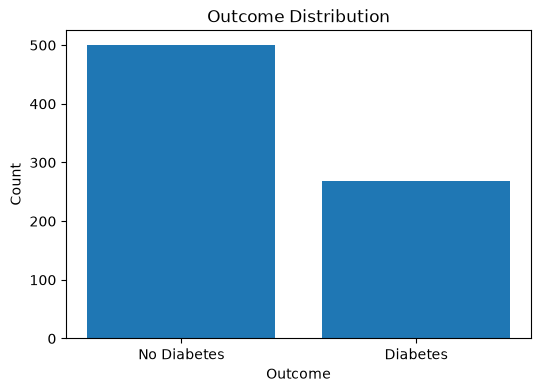

In [172]:
# Plot the target distribution
plt.figure(figsize=(6, 4))
plt.bar(df["Outcome"].value_counts().index,df["Outcome"].value_counts().values)
plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)

plt.show()

## Target Distribution

The dataset is not perfectly balanced.

About 65% of patients do not have diabetes, while about 35% have diabetes.

This means there is a mild class imbalance.

Because this is a medical classification problem, accuracy alone is not enough. Recall for class 1 is important because we want to detect as many diabetic patients as possible.

In [173]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [174]:
# Compare average Glucose between diabetes and no diabetes
df.groupby("Outcome")["Glucose"].mean()

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64

<Figure size 600x400 with 0 Axes>

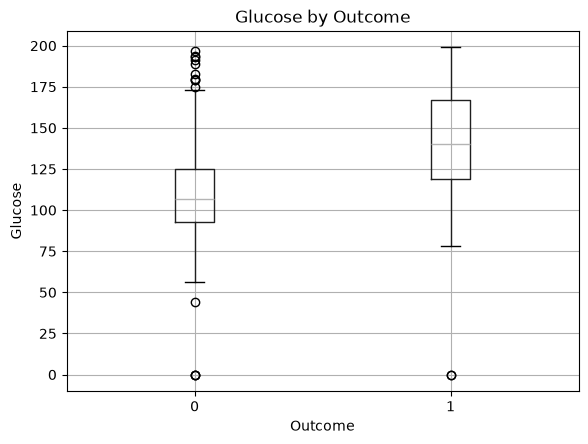

In [175]:
# Plot Glucose distribution by Outcome
plt.figure(figsize=(6, 4))

df.boxplot(column="Glucose", by="Outcome")

plt.title("Glucose by Outcome")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Glucose")

plt.show()

In [176]:
df.groupby("Outcome")["BMI"].mean()

Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64

<Figure size 600x400 with 0 Axes>

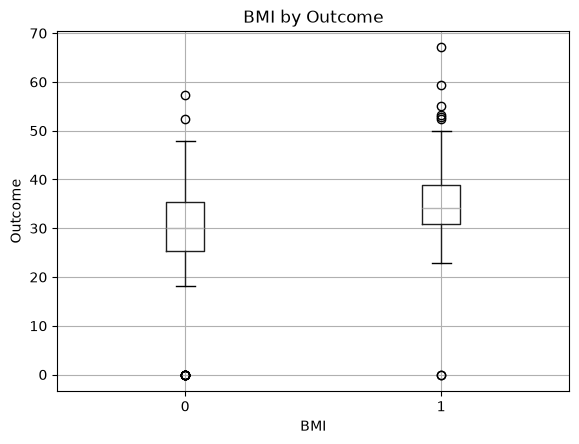

In [177]:
plt.figure(figsize=(6,4))
df.boxplot(column="BMI", by="Outcome")
plt.title("BMI by Outcome")
plt.suptitle("")
plt.xlabel("BMI")
plt.ylabel("Outcome")
plt.show()


In [178]:
df.groupby("Outcome")["Age"].mean()

Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64

<Figure size 600x400 with 0 Axes>

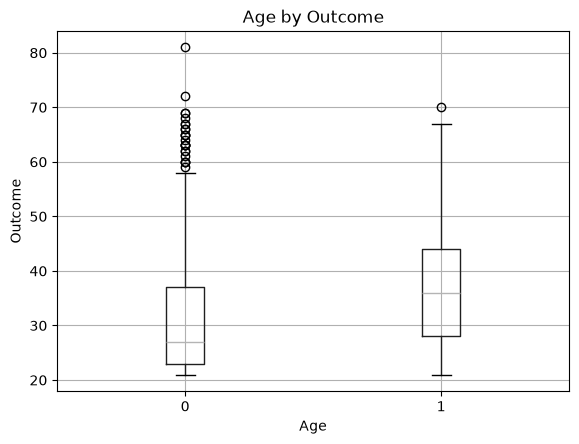

In [179]:
plt.figure(figsize=(6,4))
df.boxplot(column="Age",by="Outcome")
plt.suptitle("")
plt.xlabel("Age")
plt.ylabel("Outcome")
plt.title("Age by Outcome")
plt.show()

## Medical Feature Analysis

I compared Glucose, BMI, and Age between patients with diabetes and patients without diabetes.

I also checked zero values in medical columns because some zero values are not medically realistic, such as Glucose = 0, BloodPressure = 0, and BMI = 0.

These zero values may represent missing data and should be handled before training the model.

In [180]:
# Columns where zero values may be medically unrealistic
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts=(df[zero_cols]==0).sum()
zero_counts

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [181]:
# Replace zero values with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

In [182]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [183]:
(df[zero_cols] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

## Handling Unrealistic Zero Values

Some medical columns had zero values that are not realistic, such as Glucose, BloodPressure, Insulin, SkinThickness, and BMI.

I replaced these zero values with NaN so they can be treated as missing values in the preprocessing step.

I did not replace zero values in Pregnancies because having zero pregnancies is medically possible.

In [184]:
# Convert object columns back to numeric
numeric_cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[numeric_cols_to_fix] = df[numeric_cols_to_fix].apply(pd.to_numeric, errors="coerce")

In [185]:
df[zero_cols]=df[zero_cols].fillna(df[zero_cols].median())
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## Note About Missing Values

Some columns had many unrealistic zero values.

Insulin and SkinThickness had the highest number of missing values after replacing zeros with NaN.

For this project, I filled missing values using the median because it is simple and robust to outliers.

However, columns with a high percentage of missing values may need more careful handling in a real medical machine learning project.

In [186]:
# Check missing values after filling with median
df[zero_cols].isna().sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

## Filling Missing Values

After replacing unrealistic zero values with NaN, I filled the missing values using the median of each column.

I used the median because it is more robust to outliers than the mean.

In [187]:
# Show all correlations with Outcome
corr = df.corr(numeric_only=True)["Outcome"].sort_values(ascending=False)

print(corr)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [198]:
X=df.drop(columns="Outcome")
y=df["Outcome"]
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [202]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

## Logistic Regression Model

I started with Logistic Regression as a baseline model.

Logistic Regression is commonly used for binary classification problems.

In this project, it predicts whether a patient has diabetes or not.

In [221]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)




In [222]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("accuracy : ", accuracy)
print("precision : ", precision)
print("recall : ", recall)
print("f1 : ", f1)

accuracy :  0.7077922077922078
precision :  0.6
recall :  0.5
f1 :  0.5454545454545454


In [223]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [224]:
print(confusion_matrix(y_test,y_pred))

[[82 18]
 [27 27]]


## Logistic Regression Evaluation

The Logistic Regression model achieved an accuracy of about 70.8%.

However, accuracy alone is not enough for this medical classification problem.

The recall for class 1 diabetes is 0.50, which means the model detected only 50% of diabetic patients.

The confusion matrix shows that the model correctly detected 27 diabetic patients, but missed 27 diabetic patients.

False negatives are important in this project because missing a diabetic patient can be risky.

Therefore, this model is a good baseline, but it needs improvement.

## Training Multiple Models

I trained multiple classification models to compare their performance.

The models are:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- SVM

Comparing multiple models helps us choose the best model for the problem.

In [229]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}
results=[]
for model_name,model in models.items():
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
    "Model": model_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
    })
results_df=pd.DataFrame(results)
results_df.sort_values(by="Recall",ascending=False)
    

,Model,Accuracy,Precision,Recall,F1-score
1,KNN,0.753247,0.660000,0.611111,0.634615
3,Random Forest,0.779221,0.717391,0.611111,0.660000
4,SVM,0.740260,0.652174,0.555556,0.600000
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
2,Decision Tree,0.681818,0.553191,0.481481,0.514851


In [232]:
from sklearn.metrics import roc_auc_score

roc_results=[]
for model_name,model in models.items():
    model.fit(X_train_scaled,y_train)
    if hasattr (model,"predict_proba"):
        y_proba=model.predict_proba(X_test_scaled)[:,1]
        roc_auc=roc_auc_score(y_test,y_proba)
    else:
        roc_auc=None
    roc_results.append({
        "Model":model,
        "ROC_AUC":roc_auc
    })
roc_results_df = pd.DataFrame(roc_results)

roc_results_df.sort_values(by="ROC_AUC",ascending=False)


,Model,ROC_AUC
3,"(DecisionTreeClassifier(max_features='sqrt', r...",0.817870
0,LogisticRegression(max_iter=1000),0.812963
1,KNeighborsClassifier(),0.788611
2,DecisionTreeClassifier(random_state=42),0.635741
4,SVC(),NaN
